<a href="https://colab.research.google.com/github/Calebchike/Bitcoin-EDA/blob/main/Bitcoin_EDA_2014_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Module**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Import Data**

In [2]:
file_path = "https://raw.githubusercontent.com/Calebchike/Bitcoin-EDA/refs/heads/main/bitcoin_dataset.csv"
df = pd.read_csv(file_path)
df.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


## **Duplicate dataframe and Set Date Column as index**

Create dataframe `bitcoin` a duplicate of the `df` dataframe.
Set the date column as the dataframe index.

In [3]:
bitcoin = df.copy()
bitcoin['Date'] = pd.to_datetime(df['Date'])
bitcoin.set_index('Date', inplace=True)
bitcoin.head(5)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


# Questions About the Bitcoin Dataset

# **Price Behaviour**

## **Q1**. What was the total return from `2014` to `2026`, and what does $1,000 invested at the start become?

In [4]:
# Extract the first available starting price in 2014
price_2014 = bitcoin.loc['2014'].iloc[0]['Close']

# Extract the last available price in 2026
price_2026 = bitcoin.loc['2026'].iloc[-1]['Close']

# Calculate Total Return
total_return = ((price_2026 - price_2014) / price_2014) * 100

# Calculate Investment Growth
initial_investment = 1000
ending_value = initial_investment * (price_2026 / price_2014)

# Print results
print(f"Bitcoin Price (Start 2014): ${price_2014:,.2f}")
print(f"Bitcoin Price (Latest 2026): ${price_2026:,.2f}\n")
print(f"Total Return (2014-2026): {total_return:,.2f}%")
print(f"A $1,000 investment would become: ${ending_value:,.2f}")

Bitcoin Price (Start 2014): $457.33
Bitcoin Price (Latest 2026): $60,922.67

Total Return (2014-2026): 13,221.26%
A $1,000 investment would become: $133,212.63


## **Q2**. Which year had the best return? Which had the worst? By how much?

In [5]:
# Group by the year of the date index and get the first and last close price of each year
yearly_prices = bitcoin.groupby(bitcoin.index.year)['Close'].agg(['first', 'last'])

# Calculate the annual percentage return for each year
# Formula: ((End Price - Start Price) / Start Price) * 100
yearly_prices['Return (%)'] = ((yearly_prices['last'] - yearly_prices['first']) / yearly_prices['first']) * 100

# Identify the year with the best (maximum) return
best_year = yearly_prices['Return (%)'].idxmax()
best_return = yearly_prices['Return (%)'].max()

# Identify the year with the worst (minimum) return
worst_year = yearly_prices['Return (%)'].idxmin()
worst_return = yearly_prices['Return (%)'].min()

# Calculate the absolute difference between the best and worst annual returns
return_difference = best_return - worst_return

# Print the findings clearly
print(f"Best Year: {best_year} with a return of {best_return:,.2f}%")
print(f"Worst Year: {worst_year} with a return of {worst_return:,.2f}%")
print(f"The difference between the best and worst year is {return_difference:,.2f}%.")


Best Year: 2017 with a return of 1,318.02%
Worst Year: 2018 with a return of -72.60%
The difference between the best and worst year is 1,390.61%.


## **Q3**. How many days did it take to 10x, 100x, 200x from the starting price?

In [6]:
# Get the baseline starting price and its corresponding date
start_price = bitcoin['Close'].iloc[0]
start_date = bitcoin.index[0]

# Define the target milestones (10x, 100x, 200x)
multipliers = [10, 100, 200]

print(f"Baseline Start Date: {start_date.strftime('%Y-%m-%d')}")
print(f"Baseline Start Price: ${start_price:,.2f}\n")

# Iterate through each multiplier to find the time elapsed
for target in multipliers:
    # Calculate the dollar value needed to reach the milestone
    target_price = start_price * target

    # Filter the dataframe to only find days where the price met or exceeded the target
    milestone_df = bitcoin[bitcoin['Close'] >= target_price]

    # Check if Bitcoin has actually reached this milestone yet
    if not milestone_df.empty:
        # Extract the very first date this milestone condition was met
        achieved_date = milestone_df.index[0]

        # Calculate the delta between the milestone date and the start date
        days_taken = (achieved_date - start_date).days

        # Print the result
        print(f" {target}x Milestone (${target_price:,.2f}):")
        print(f"   - Reached on: {achieved_date.strftime('%Y-%m-%d')}")
        print(f"   - Time elapsed: {days_taken:,} days (approx. {days_taken/365.25:.1f} years)\n")
    else:
        print(f" {target}x Milestone (${target_price:,.2f}): Not reached yet in this dataset.\n")

Baseline Start Date: 2014-09-17
Baseline Start Price: $457.33

 10x Milestone ($4,573.34):
   - Reached on: 2017-08-29
   - Time elapsed: 1,077 days (approx. 2.9 years)

 100x Milestone ($45,733.40):
   - Reached on: 2021-02-08
   - Time elapsed: 2,336 days (approx. 6.4 years)

 200x Milestone ($91,466.80):
   - Reached on: 2024-11-19
   - Time elapsed: 3,716 days (approx. 10.2 years)



## **Q4**.  What is the largest single-day gain and the largest single-day loss, and what happened that day?

In [7]:
# Calculate the daily percentage change based on the closing price
bitcoin['Daily_Return'] = bitcoin['Close'].pct_change() * 100

# Extract the date and value for the absolute largest daily gain
max_gain_date = bitcoin['Daily_Return'].idxmax()
max_gain_value = bitcoin['Daily_Return'].max()

# Extract the date and value for the absolute largest daily loss
max_loss_date = bitcoin['Daily_Return'].idxmin()
max_loss_value = bitcoin['Daily_Return'].min()

# print the result
print(f" Largest Single-Day Gain: {max_gain_value:.2f}% on {max_gain_date.strftime('%Y-%m-%d')}")
print(f" Largest Single-Day Loss: {max_loss_value:.2f}% on {max_loss_date.strftime('%Y-%m-%d')}")

 Largest Single-Day Gain: 25.25% on 2017-12-07
 Largest Single-Day Loss: -37.17% on 2020-03-12


## **Q5**.  What percent of days closed green versus red? Is it close to a coin flip?

In [8]:
# Calculate daily returns (percentage change from previous day's close)
bitcoin['Daily_Return'] = bitcoin['Close'].pct_change() * 100

# Count the days based on performance conditions
green_days = (bitcoin['Daily_Return'] > 0).sum()
red_days = (bitcoin['Daily_Return'] < 0).sum()
flat_days = (bitcoin['Daily_Return'] == 0).sum()

# Calculate the total valid trading days (excluding the first row, which is NaN)
total_days = bitcoin['Daily_Return'].dropna().count()

# Compute the percentages
pct_green = (green_days / total_days) * 100
pct_red = (red_days / total_days) * 100
pct_flat = (flat_days / total_days) * 100

# Print the result
print(f" Green Days (Closed Up):   {green_days:,} ({pct_green:.2f}%)")
print(f" Red Days (Closed Down):   {red_days:,} ({pct_red:.2f}%)")
print(f" Flat Days (No Change):    {flat_days:,} ({pct_flat:.2f}%)")
print("-" * 45)
print(f"Total Evaluated Days:       {total_days:,}")

 Green Days (Closed Up):   2,242 (52.40%)
 Red Days (Closed Down):   2,036 (47.58%)
 Flat Days (No Change):    1 (0.02%)
---------------------------------------------
Total Evaluated Days:       4,279


# **Volatility and Risk**

##  **Q1**.   What is the rolling 30-day volatility, and which periods spike hardest?

In [9]:
# Calculate daily percentage returns
bitcoin['Daily_Return'] = bitcoin['Close'].pct_change() * 100

# Calculate the Standard Deviation of daily returns
bitcoin['Rolling_Vol_30'] = bitcoin['Daily_Return'].rolling(window=30).std()

bitcoin['Annualized_Vol_30'] = bitcoin['Rolling_Vol_30'] * np.sqrt(365)

# Identify the top 5 periods where volatility spiked the hardest
# We use dropna() to ignore the first 29 days which don't have enough data
top_vol_days = bitcoin['Rolling_Vol_30'].dropna().nlargest(5)

# Print the highest volatility spikes found in the dataset
print("Top 5 Dates with the Highest 30-Day Rolling Volatility Spikes:")
print("-" * 65)
for date, vol in top_vol_days.items():
    annualized = bitcoin.loc[date, 'Annualized_Vol_30']
    print(f"{date.strftime('%Y-%m-%d')}: Daily Vol = {vol:.2f}% | Annualized Vol = {annualized:.2f}%")

Top 5 Dates with the Highest 30-Day Rolling Volatility Spikes:
-----------------------------------------------------------------
2020-04-06: Daily Vol = 9.13% | Annualized Vol = 174.49%
2020-04-03: Daily Vol = 9.06% | Annualized Vol = 173.05%
2020-04-02: Daily Vol = 9.06% | Annualized Vol = 173.04%
2020-04-10: Daily Vol = 9.05% | Annualized Vol = 172.95%
2020-03-31: Daily Vol = 9.05% | Annualized Vol = 172.91%


##  **Q2**.   What is the largest drawdown from peak to trough, and how long did it take to recover?

In [10]:
# Compute a running, rolling maximum price up to each point in time
bitcoin['Rolling_Max'] = bitcoin['Close'].cummax()

# Calculate daily drawdown as the percentage distance from that rolling maximum
bitcoin['Drawdown'] = ((bitcoin['Close'] - bitcoin['Rolling_Max']) / bitcoin['Rolling_Max']) * 100

# Locate the worst drawdown value and its date
max_drawdown = bitcoin['Drawdown'].min()
trough_date = bitcoin['Drawdown'].idxmin()

# Find the exact date when the rolling max equaled the peak value at the trough
peak_value = bitcoin.loc[trough_date, 'Rolling_Max']
peak_date = bitcoin.loc[:trough_date][bitcoin.loc[:trough_date, 'Close'] == peak_value].index[0]

# Trace forward to find when the price fully recovered to breach that previous peak
recovery_df = bitcoin.loc[trough_date:][bitcoin.loc[trough_date:, 'Close'] >= peak_value]

if not recovery_df.empty:
    recovery_date = recovery_df.index[0]
    days_to_trough = (trough_date - peak_date).days
    days_to_recover = (recovery_date - trough_date).days
    total_cycle_days = (recovery_date - peak_date).days

    print(f"Maximum Drawdown: {max_drawdown:.2f}%")
    print(f"Peak Date:         {peak_date.strftime('%Y-%m-%d')} (${peak_value:,.2f})")
    print(f"Trough Date:       {trough_date.strftime('%Y-%m-%d')} (${bitcoin.loc[trough_date, 'Close']:,.2f})")
    print(f"Recovery Date:     {recovery_date.strftime('%Y-%m-%d')}")
    print("-" * 50)
    print(f"Days from Peak to Bottom (Crash Phase): {days_to_trough} days")
    print(f"Days from Bottom to Recovery (Rally Phase): {days_to_recover} days")
    print(f"Total Peak-to-Peak Recovery Cycle Timeline: {total_cycle_days} days")
else:
    print(f"Maximum Drawdown: {max_drawdown:.2f}%")
    print(f"Peak Date:         {peak_date.strftime('%Y-%m-%d')} (${peak_value:,.2f})")
    print(f"Trough Date:       {trough_date.strftime('%Y-%m-%d')}")
    print(f"Status:            Still in progress. The price has not yet recovered to its peak.")

Maximum Drawdown: -83.40%
Peak Date:         2017-12-16 ($19,497.40)
Trough Date:       2018-12-15 ($3,236.76)
Recovery Date:     2020-11-30
--------------------------------------------------
Days from Peak to Bottom (Crash Phase): 364 days
Days from Bottom to Recovery (Rally Phase): 716 days
Total Peak-to-Peak Recovery Cycle Timeline: 1080 days


##  **Q3**.    Does volume predict direction, or is the correlation near zero like the original found?

In [11]:
# Calculate Daily Price Return and Absolute (Magnitude) Return
bitcoin['Daily_Return'] = bitcoin['Close'].pct_change() * 100
bitcoin['Absolute_Return'] = bitcoin['Daily_Return'].abs()

# Calculate Daily Volume Percentage Change
# Using pct_change because raw volume grows exponentially over the years
bitcoin['Volume_Change'] = bitcoin['Volume'].pct_change() * 100

# Create a correlation matrix comparing Volume to both Directional and Absolute returns
correlation_matrix = bitcoin[['Volume_Change', 'Daily_Return', 'Absolute_Return']].corr()

print("--- Pearson Correlation Matrix ---")
print(correlation_matrix)


--- Pearson Correlation Matrix ---
                 Volume_Change  Daily_Return  Absolute_Return
Volume_Change         1.000000      0.033647         0.351137
Daily_Return          0.033647      1.000000         0.055939
Absolute_Return       0.351137      0.055939         1.000000


##  **Q4**.     Is volatility clustered — do high-volatility days follow other high-volatility days?

In [12]:
# Calculate daily returns and their absolute values (magnitude of volatility)
bitcoin['Daily_Return'] = bitcoin['Close'].pct_change() * 100
bitcoin['Absolute_Return'] = bitcoin['Daily_Return'].abs()

# Print day-to-day correlation
day_to_day_corr = bitcoin['Absolute_Return'].corr(bitcoin['Absolute_Return'].shift(1))
print(f"The day to day Correlation: {day_to_day_corr:.3f}")

The day to day Correlation: 0.211


# **Seasonality and Cycles**

##  **Q1**.      Is there a “best month” or “worst month” pattern across years e.g. September weakness or October strength?

--- Bitcoin Historical Seasonality Performance Metrics ---
     Median Return (%)  Mean Return (%)  Win Rate (%)
Jan              -3.46            -1.15         50.00
Feb              11.86            10.19         75.00
Mar              -0.16             0.48         50.00
Apr               9.70            10.16         66.67
May               3.37             8.08         50.00
Jun              -0.51             0.32         50.00
Jul               8.20             9.03         72.73
Aug              -7.88            -0.15         27.27
Sep              -3.08            -1.82         45.45
Oct              12.94            16.63         75.00
Nov               7.58             7.51         58.33
Dec              -3.16             7.14         41.67


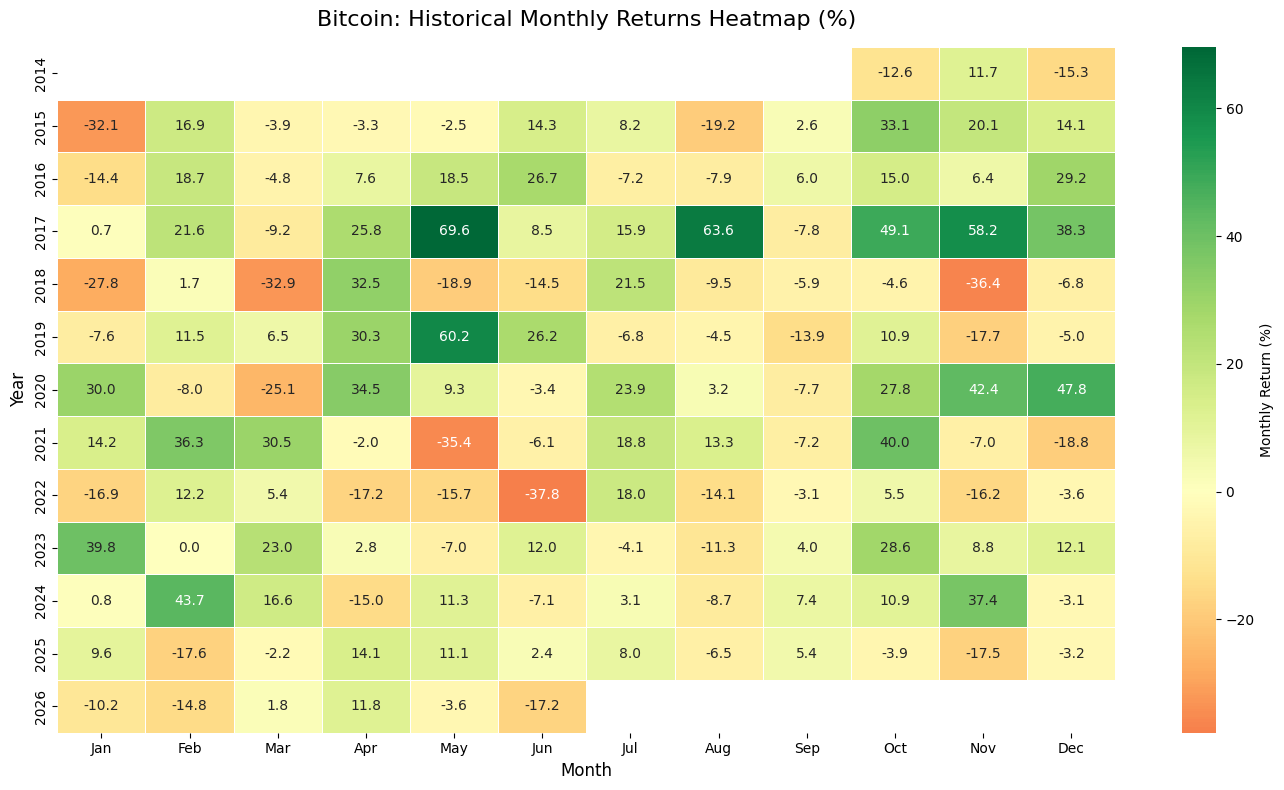

In [13]:
# Resample daily data to get the final closing price of every month
monthly_closes = bitcoin['Close'].resample('ME').last()

# Calculate monthly percentage returns
monthly_returns = monthly_closes.pct_change() * 100

# Transform the series into a DataFrame with Year and Month columns
monthly_df = monthly_returns.to_frame(name='Return')
monthly_df['Year'] = monthly_df.index.year
monthly_df['Month'] = monthly_df.index.month

# Pivot the data into a Year x Month matrix grid
# Rows = Years, Columns = Months (1-12)
seasonality_matrix = monthly_df.pivot(index='Year', columns='Month', values='Return')

# Map column numbers to standard 3-letter month names for readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
seasonality_matrix.columns = month_names

# Calculate historical aggregations (Median and Mean) for each calendar month
# Median is preferred in because it minimizes the impact of extreme outlier years
monthly_stats = pd.DataFrame({
    'Median Return (%)': seasonality_matrix.median(),
    'Mean Return (%)': seasonality_matrix.mean(),
    'Win Rate (%)': (seasonality_matrix > 0).sum() / seasonality_matrix.notna().sum() * 100
})

print("--- Bitcoin Historical Seasonality Performance Metrics ---")
print(monthly_stats.round(2))

# Generate a Seasonal Heatmap for your EDA presentation
plt.figure(figsize=(14, 8))
sns.heatmap(seasonality_matrix, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            cbar_kws={'label': 'Monthly Return (%)'}, linewidths=0.5)

plt.title('Bitcoin: Historical Monthly Returns Heatmap (%)', fontsize=16, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.savefig('bitcoin_monthly_seasonality.png')
plt.show()

##  **Q2**.       Does the four-year halving cycle show up in the return data?

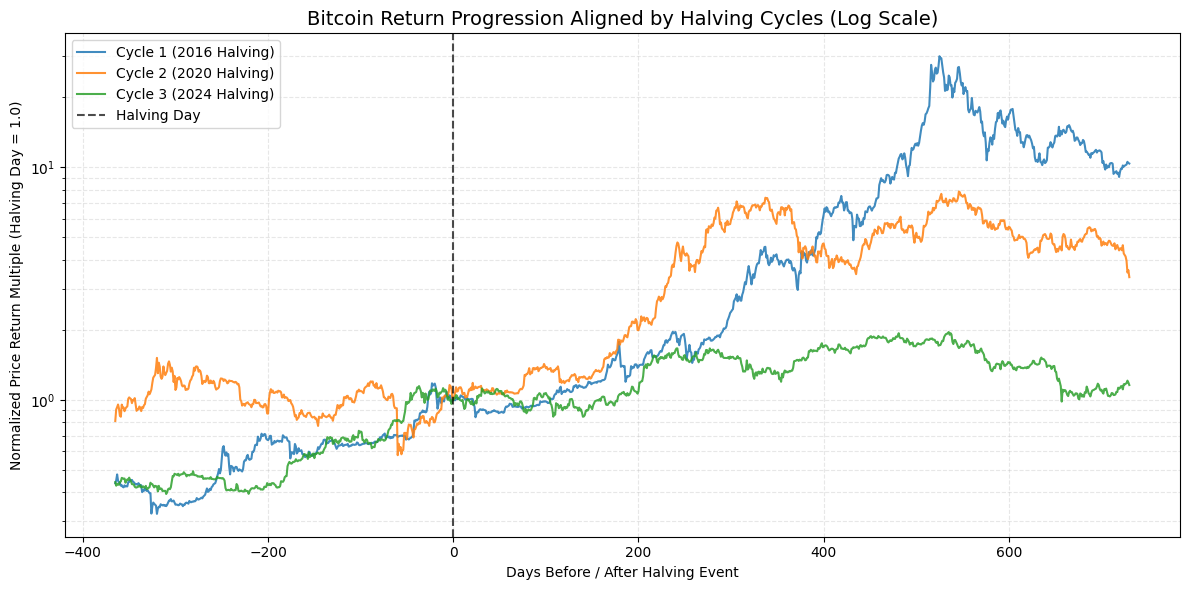

In [14]:
# Define the exact historic halving dates
halving_dates = [
    pd.to_datetime('2012-11-28'),
    pd.to_datetime('2016-07-09'),
    pd.to_datetime('2020-05-11'),
    pd.to_datetime('2024-04-19')
]

# Filter out halvings that occur before your dataset's starting index
valid_halvings = [d for d in halving_dates if d >= bitcoin.index[0]]

# Track price progression normalized to 100 on the day of each halving
plt.figure(figsize=(12, 6))

for i, h_date in enumerate(valid_halvings):
    # Slice a window around the halving date (-1 year to +2 years)
    start_w = h_date - pd.Timedelta(days=365)
    end_w = h_date + pd.Timedelta(days=730)

    # Extract the subset window from our main dataframe
    cycle_df = bitcoin.loc[start_w:end_w].copy()

    if not cycle_df.empty:
        # Calculate the number of days elapsed relative to the halving date
        cycle_df['Days_From_Halving'] = (cycle_df.index - h_date).days

        # Get the closing price exactly on the halving day to use as a baseline
        # If the exact date is missing, pick the closest available row
        halving_price = bitcoin.loc[bitcoin.index.asof(h_date)]['Close']

        # Normalize the price performance (Halving Day Price = 1.0 or 100%)
        cycle_df['Normalized_Return'] = cycle_df['Close'] / halving_price

        # Plot the cycle line
        plt.plot(cycle_df['Days_From_Halving'], cycle_df['Normalized_Return'],
                 label=f'Cycle {i+1} ({h_date.year} Halving)', alpha=0.85)

# Chart Formating
plt.axvline(0, color='black', linestyle='--', alpha=0.7, label='Halving Day')
plt.yscale('log') # Log scale is essential due to the massive asymmetry in early cycles
plt.title('Bitcoin Return Progression Aligned by Halving Cycles (Log Scale)', fontsize=14)
plt.xlabel('Days Before / After Halving Event')
plt.ylabel('Normalized Price Return Multiple (Halving Day = 1.0)')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('halving_cycle_alignment.png')
plt.show()

##  **Q3**.        Are weekday returns different from weekend returns ?

--- Weekday vs. Weekend Structural Performance ---
               Average_Return  Median_Return  Volatility_Std  Average_Volume
Market_Period                                                               
Weekday                0.2010         0.1104          3.7577    2.432397e+10
Weekend                0.1127         0.0996          2.7142    1.724729e+10


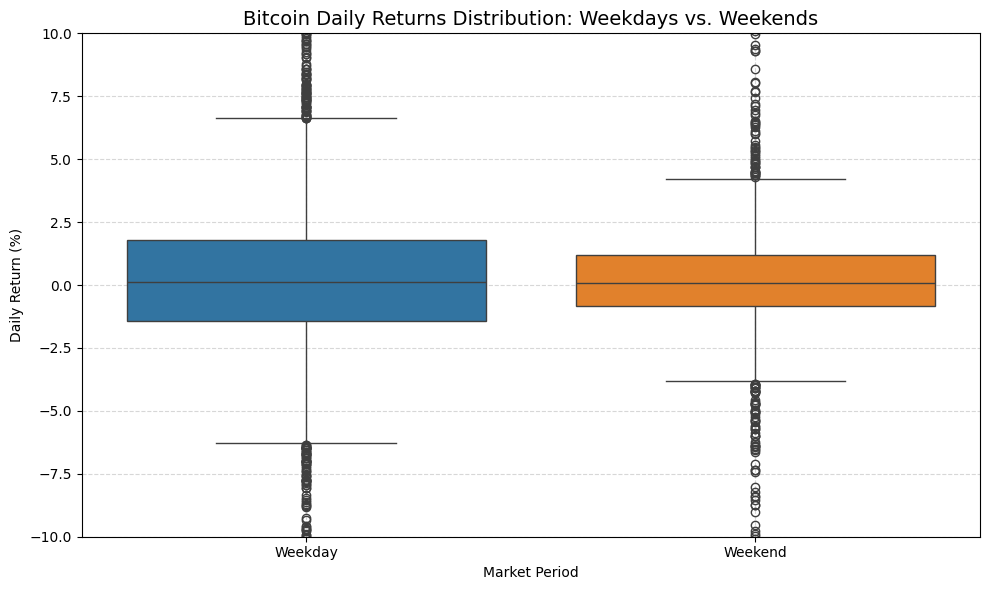

In [15]:
# Calculate percentage daily returns
bitcoin['Daily_Return'] = bitcoin['Close'].pct_change() * 100

# Extract the days of the week (Monday-0 through Sunday-6)
bitcoin['Day_of_Week'] = bitcoin.index.dayofweek

# Classify each day as either a Weekday or Weekend
# np.where sets rows to 'Weekend' if day is 5 (Sat) or 6 (Sun), else 'Weekday'
bitcoin['Market_Period'] = bitcoin['Day_of_Week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Compute performance metrics comparing the two periods
grouped_stats = bitcoin.groupby('Market_Period').agg(
    Average_Return=('Daily_Return', 'mean'),
    Median_Return=('Daily_Return', 'median'),
    Volatility_Std=('Daily_Return', 'std'),
    Average_Volume=('Volume', 'mean')
)

print("--- Weekday vs. Weekend Structural Performance ---")
print(grouped_stats.round(4))

# Create a Box Plot to visualize the return distribution and outliers
plt.figure(figsize=(10, 6))
# We clip the y-axis slightly to focus on core distributions rather than extreme outliers
sns.boxplot(data=bitcoin, x='Market_Period', y='Daily_Return', hue='Market_Period', palette=['#1f77b4', '#ff7f0e'], legend=False)
plt.ylim(-10, 10)
plt.title('Bitcoin Daily Returns Distribution: Weekdays vs. Weekends', fontsize=14)
plt.xlabel('Market Period')
plt.ylabel('Daily Return (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('weekday_vs_weekend.png')
plt.show()

Bitcoin Average Daily Return

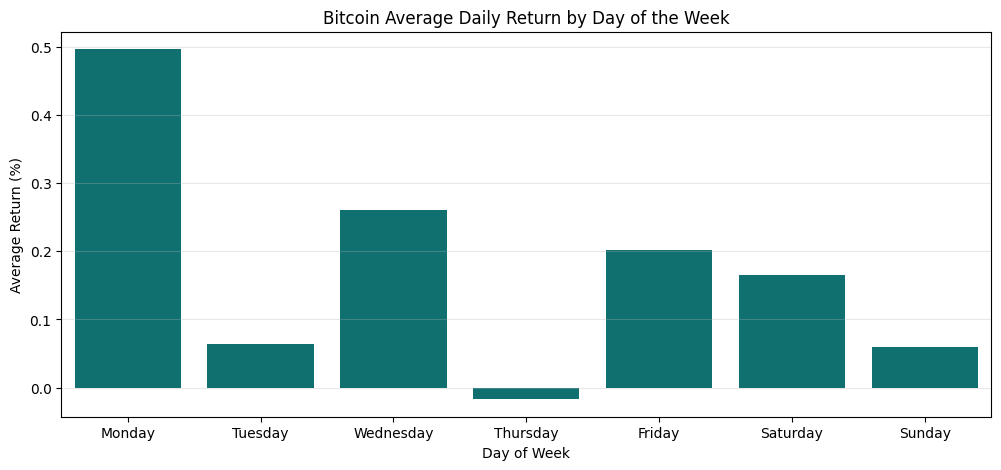

In [16]:
# Group by the specific day names
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
bitcoin['Day_Name'] = bitcoin.index.day_name()

plt.figure(figsize=(12, 5))
sns.barplot(data=bitcoin, x='Day_Name', y='Daily_Return', order=day_names, errorbar=None, color='teal')
plt.title('Bitcoin Average Daily Return by Day of the Week')
plt.ylabel('Average Return (%)')
plt.xlabel('Day of Week')
plt.grid(True, axis='y', alpha=0.3)